# Cell-State Differential Expression

> **Where this fits:** Steps 1–7 built the atlas — 204,883 cells mapped into a 2D embedding, annotated with 22 cell types and 42 cell states. This notebook asks the first analytical question: *which cell states actually change with obesity and exercise?*
>
> This notebook reproduces Figure 4F/G/H from Yang et al. (2022).

## The problem this step solves

The bulk RNA-seq pipeline found 1,386 differentially expressed genes (DEGs — genes significantly more or less active in one condition vs another) across the three tissues. But bulk RNA-seq gives you a tissue average. If you find that the gene *Thbs1* goes up in visceral fat with obesity, you don't know *which cells* in the tissue are responsible — it could be the fat cells themselves, the immune cells, the stem cells, or all of them equally.

This is the core question the single-cell atlas was built to answer. By testing each cell state separately, the paper showed that the vast majority of the visceral fat response to obesity and exercise is concentrated in mesenchymal stem cells (MSCs — umbrella term for the stem and progenitor cells in fat and muscle), not in the mature fat cells or immune cells that dominate the tissue by volume.

**If you skip this analysis**, you would conclude from bulk data that the entire tissue responds to exercise — which is misleading. The actual answer is that a small fraction of rare stem cells drive most of the transcriptional response. That changes what therapeutic targets you would pursue.

## Why vWAT first

Visceral white adipose tissue (vWAT — fat around internal organs) shows the strongest signal in this dataset: 502 cell-state-level DEGs vs 139 in subcutaneous fat (scWAT — fat just under the skin) and 290 in skeletal muscle (SkM). vWAT is also the more metabolically harmful fat depot — it's more strongly associated with insulin resistance and type 2 diabetes in humans. We start here because the signal is clearest and the biological stakes are highest.

## The two contrasts we run (in this order)

| Contrast | Comparison | Question |
|----------|-----------|----------|
| Obesity | SH vs SC | What does high-fat diet (HFD) do to each cell state? |
| Exercise | TC vs SC | What does exercise training do on a healthy diet? |

We run obesity first because it establishes the baseline perturbation. Exercise is more interpretable once you know what obesity does.

The rescue contrast (TH vs SH — exercise in already-obese animals) is the most therapeutically interesting but will be added in the next iteration. **The paper's 502 vWAT DEG count spans all three contrasts** — your count across two contrasts will be lower; that's expected.

## The method: Wilcoxon rank-sum test per cell state

The paper used a Wilcoxon rank-sum test run separately within each cell state (confirmed from Figure 4 legend: "by Wilcoxon rank-sum test").

**ML analogy:** Think of this as a stratified statistical test. Instead of one test across all 204,883 cells, you run one test per stratum (cell state × tissue combination). Each test asks: within the IPC (interstitial progenitor cell — an undifferentiated adipose stem cell state) population in vWAT, do SH cells have systematically higher expression of gene X than SC cells?

**Why Wilcoxon, not a t-test?** RNA-seq counts are not normally distributed — they're zero-inflated and right-skewed. Wilcoxon ranks the expression values rather than using their raw magnitude, making it robust to the distributional weirdness of single-cell data.

**Why not DESeq2 here?** DESeq2 (used in bulk) treats each *sample* (mouse) as an independent observation. In single-cell data, if you treat each *cell* as independent, you have pseudoreplication: the 50,000 vWAT cells came from only ~13 mice per condition. Cells within the same mouse are correlated — they share the same genetics, diet history, and batch effects. Using DESeq2 at the cell level inflates your sample size and produces false positives. Wilcoxon at the cell level has the same problem, but the paper used it — we reproduce their method faithfully here. The methodologically correct approach (pseudobulk DESeq2) is in Notebook 8.

**Thresholds (standard Seurat defaults, not stated explicitly in paper):**
- Adjusted p-value < 0.05 (Benjamini-Hochberg correction)
- |log2 fold change| > 0.25 (minimum effect size)

## Validation targets

Your output should approximate these numbers from the paper:
- **IPCs (interstitial progenitor cells) + CPs (committed preadipocytes — ASCs that have started committing to becoming fat cells) account for ~59% of total vWAT DEGs** across all three contrasts
- vWAT has 7.6× more DEGs than the next tissue in the rescue contrast (265 vs 35)
- ECM genes (*Thbs1*, *Sparc*) should appear upregulated by obesity in IPC/CP states
- Circadian genes (*Dbp*, *Tef*) should appear upregulated by exercise in IPC/CP states

## Setup

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path("../GSE183288_Single_cell_atlas.h5ad")
OUT_DIR   = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Gene lists used throughout — defined here so all cells can reference them
ECM_GENES       = ['Thbs1', 'Sparc', 'Col3a1', 'Col6a1', 'Col1a1', 'Col1a2']
CIRCADIAN_GENES = ['Dbp', 'Tef', 'Nr1d2', 'Per3', 'Hlf', 'Bmal1', 'Clock']

## Load the atlas

We load the full 204,883-cell atlas. The key columns in `adata.obs` (cell metadata) that we need:

| Column | What it contains |
|--------|------------------|
| `cell_type_label` | 22 broad cell types (e.g., ASC, FAP, Macrophage) |
| `cell_state_label` | 42 fine-grained cell states (e.g., IPC_vWAT, CP, CD142+) |
| `tissue` | scWAT, vWAT, or SkM |
| `intervention_group` | SC, TC, SH, or TH — the experimental condition |
| `sample_ID` | Which mouse the cell came from (39 samples) |

`layers['counts']` contains the raw integer counts — required for the Wilcoxon test, which should run on normalized log expression (we use the main `.X` matrix which is log-normalized).

In [2]:
adata = sc.read_h5ad(DATA_PATH)
print(f"Atlas: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"\nCell state labels (first 10):")
print(sorted(adata.obs['cell_state_label'].unique())[:10])
print(f"\nIntervention groups: {sorted(adata.obs['intervention_group'].unique())}")
print(f"Tissues: {sorted(adata.obs['tissue'].unique())}")

Atlas: 204,883 cells × 17,341 genes

Cell state labels (first 10):
['Areg', 'B_Fo', 'B_Memory', 'CD4_Memory', 'CD4_Naive', 'CD8_Cytotoxic', 'CD8_Naive', 'CP', 'Capillary', 'Epi']

Intervention groups: ['SC', 'SH', 'TC', 'TH']
Tissues: ['SM', 'scWAT', 'vWAT']


In [9]:
adata.layers['counts'][:5, :5]

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 2 stored elements and shape (5, 5)>

## Inspect cell state composition in vWAT

Before running any statistical tests, look at the data. How many cells are in each state? Are the groups balanced across conditions?

**Why this matters:** A cell state with 50 cells total cannot give you reliable DE results. The paper's approach implicitly filters low-cell states out because Wilcoxon loses power with small n. We'll make this explicit.

In [10]:
# Subset to vWAT
vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()
print(f"vWAT cells: {vwat.n_obs:,}")

vWAT cells: 78,860


In [14]:
vwat.obs.groupby(['cell_state_label', 'intervention_group'])

/var/folders/5w/mjm68_js3pn549s51dkhz_740000gp/T/ipykernel_59725/3384127703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vwat.obs.groupby(['cell_state_label', 'intervention_group'])


In [16]:
# Cell counts per state × condition
cell_counts = (
    vwat.obs
    .groupby(['cell_state_label', 'intervention_group'])
    .size()
    .unstack(fill_value=0)
)

cell_counts[:3]

/var/folders/5w/mjm68_js3pn549s51dkhz_740000gp/T/ipykernel_59725/2794089722.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['cell_state_label', 'intervention_group'])


intervention_group,SC,SH,TC,TH
cell_state_label,,,,
Areg,1555,1184,1450,2008
B_Fo,271,102,317,236
CD4_Memory,930,380,539,710


In [17]:
# Reindex columns safely — not all conditions may be present in every subset
for col in ['SC', 'TC', 'SH', 'TH']:
    if col not in cell_counts.columns:
        cell_counts[col] = 0

In [18]:
cell_counts = cell_counts[['SC', 'TC', 'SH', 'TH']]
cell_counts['total'] = cell_counts.sum(axis=1)
cell_counts = cell_counts.sort_values('total', ascending=False)

print("\nCell counts per state × condition in vWAT:")
cell_counts.to_string()[]


Cell counts per state × condition in vWAT:
intervention_group       SC    TC    SH    TH  total
cell_state_label                                    
CP                     6725  8953  2943  7380  26001
WAT_IPC                3178  3029  2534  7083  15824
Areg                   1555  1450  1184  2008   6197
NK                     1386  1848   736  1528   5498
pre_CP                 1139  1046   930  1572   4687
CD4_Memory              930   539   380   710   2559
Fibroblast              452   498   240  1168   2358
cDC2                    302   172   454   880   1808
nILC2                   497   416   261   529   1703
Treg                    295   162   396   404   1257
NKT                     328   487   116   287   1218
Capillary                24   129    26  1009   1188
M2                      129   114   222   707   1172
Tgd_CD27-               143   251   236   514   1144
CD4_Naive               361   331   113   327   1132
B_Fo                    271   317   102   236    926
CD

/var/folders/5w/mjm68_js3pn549s51dkhz_740000gp/T/ipykernel_59725/448383294.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['intervention_group', 'cell_state_label'])
/var/folders/5w/mjm68_js3pn549s51dkhz_740000gp/T/ipykernel_59725/448383294.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)


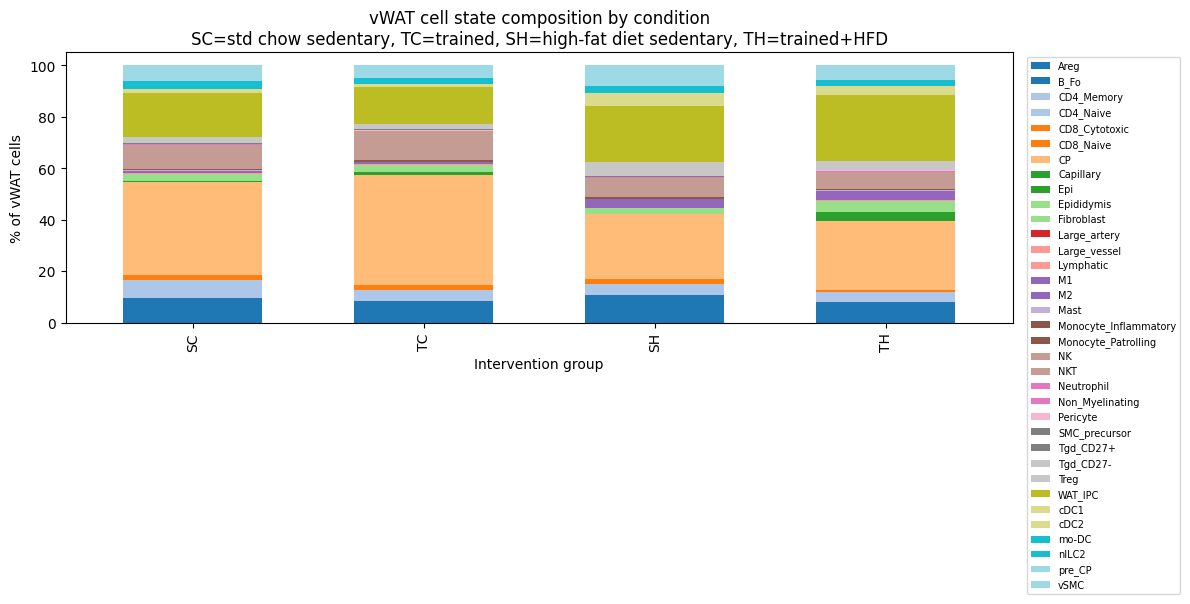


Look at this plot before running DE.
Question: do any cell states visually appear to expand or contract with HFD or training?
(That's composition change — different from gene expression change within a fixed population)


In [19]:
# Visualize: stacked bar of cell state composition by condition
# This is one of the missing visualizations from NB7 — it shows whether
# exercise or obesity reshapes the cellular composition of vWAT.
# (Compositional changes are tested rigorously in NB13 with scCODA;
# this is an exploratory look.)

comp = (
    vwat.obs
    .groupby(['intervention_group', 'cell_state_label'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
)
comp = comp.loc[['SC', 'TC', 'SH', 'TH']]

fig, ax = plt.subplots(figsize=(12, 5))
comp.plot(kind='bar', stacked=True, ax=ax, legend=True,
          colormap='tab20', width=0.6)
ax.set_xlabel('Intervention group')
ax.set_ylabel('% of vWAT cells')
ax.set_title('vWAT cell state composition by condition\n'
             'SC=std chow sedentary, TC=trained, SH=high-fat diet sedentary, TH=trained+HFD')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'vwat_cell_state_composition.pdf', bbox_inches='tight')
plt.show()

print("\nLook at this plot before running DE.")
print("Question: do any cell states visually appear to expand or contract with HFD or training?")
print("(That's composition change — different from gene expression change within a fixed population)")

## The DE function

We'll use Scanpy's `sc.tl.rank_genes_groups()` which implements Wilcoxon rank-sum internally and handles the multiple testing correction (Benjamini-Hochberg) across genes within each comparison.

**What `rank_genes_groups` does under the hood:**
1. For each gene, ranks all expression values across all cells in the two groups
2. Computes the Wilcoxon U statistic (essentially: are the ranks from group A systematically higher than group B?)
3. Converts U to a p-value
4. Applies Benjamini-Hochberg correction across all genes tested
5. Returns log2 fold change, adjusted p-value, and a score for ranking

We wrap this in a function that:
- Subsets to a specific cell state and tissue
- Runs DE between two intervention groups
- Returns a clean DataFrame of results

In [22]:
def run_wilcoxon_de(adata_subset, group_a, group_b,
                    groupby_col='intervention_group',
                    min_cells=10):
    """
    Run Wilcoxon rank-sum DE between group_a and group_b within adata_subset.

    group_a is the 'numerator' (e.g., SH for obesity contrast).
    group_b is the 'denominator' / reference (e.g., SC).
    Positive log2FC means higher expression in group_a.

    Returns None if either group has fewer than min_cells cells.
    """
    n_a = (adata_subset.obs[groupby_col] == group_a).sum()
    n_b = (adata_subset.obs[groupby_col] == group_b).sum()

    if n_a < min_cells or n_b < min_cells:
        return None

    # Subset to just the two groups we're comparing
    mask = adata_subset.obs[groupby_col].isin([group_a, group_b])
    sub  = adata_subset[mask].copy()

    # rank_genes_groups tests each group vs all others.
    # With only 2 groups, 'groups=[group_a]' gives us group_a vs group_b.
    sc.tl.rank_genes_groups(
        sub,
        groupby=groupby_col,
        groups=[group_a],
        reference=group_b,
        method='wilcoxon',
        corr_method='benjamini-hochberg',
        tie_correct=True,   # correct for tied ranks — important for zero-inflated scRNA data
        use_raw=False,      # use .X (log-normalized) not raw counts
    )

    # Extract results into a clean DataFrame
    result = sc.get.rank_genes_groups_df(
        sub,
        group=group_a,
        pval_cutoff=None,   # return all genes; we filter below
        log2fc_min=None,
    )
    result = result.rename(columns={
        'names': 'gene',
        'scores': 'score',
        'logfoldchanges': 'log2FC',
        'pvals': 'pval',
        'pvals_adj': 'padj',
    })
    result['contrast']  = f"{group_a}_vs_{group_b}"
    result['n_a'] = n_a
    result['n_b'] = n_b

    return result


def get_sig(df, padj_thresh=0.05, lfc_thresh=0.25):
    """Filter to significant DEGs using the paper's implicit thresholds."""
    return df[
        (df['padj'] < padj_thresh) &
        (df['log2FC'].abs() > lfc_thresh)
    ].copy()


print("Functions defined.")

Functions defined.


## Contrast 1: Obesity effect in vWAT (SH vs SC)

**Biological question:** What does a high-fat diet (HFD — the obesity model) do to gene expression within each cell state in visceral fat?

- **SH** = Sedentary + High-fat diet (obese, no exercise)
- **SC** = Sedentary + Standard chow (lean control)

Positive log2FC = gene is *higher* in obese (SH) animals.
Negative log2FC = gene is *lower* in obese animals (suppressed by HFD).

We run this separately for each cell state in vWAT. Cell states with fewer than 10 cells in either group are skipped — not enough data to estimate differences reliably.

In [24]:
# Run obesity contrast (SH vs SC) for every cell state in vWAT
vwat_cell_states = sorted(vwat.obs['cell_state_label'].unique())
print(f"Cell states in vWAT: {len(vwat_cell_states)}")
print(vwat_cell_states)

obesity_results = {}

for state in vwat_cell_states:
    state_cells = vwat[vwat.obs['cell_state_label'] == state]
    result = run_wilcoxon_de(state_cells, group_a='SH', group_b='SC')

    if result is None:
        print(f"  {state}: skipped (too few cells)")
        continue

    sig = get_sig(result)
    obesity_results[state] = result
    # print(f"  {state}: {result['n_a'].iloc[0]} SH cells, {result['n_b'].iloc[0]} SC cells → {len(sig)} DEGs")

# print(f"\nTotal cell states tested: {len(obesity_results)}")

Cell states in vWAT: 35
['Areg', 'B_Fo', 'CD4_Memory', 'CD4_Naive', 'CD8_Cytotoxic', 'CD8_Naive', 'CP', 'Capillary', 'Epi', 'Epididymis', 'Fibroblast', 'Large_artery', 'Large_vessel', 'Lymphatic', 'M1', 'M2', 'Mast', 'Monocyte_Inflammatory', 'Monocyte_Patrolling', 'NK', 'NKT', 'Neutrophil', 'Non_Myelinating', 'Pericyte', 'SMC_precursor', 'Tgd_CD27+', 'Tgd_CD27-', 'Treg', 'WAT_IPC', 'cDC1', 'cDC2', 'mo-DC', 'nILC2', 'pre_CP', 'vSMC']
1184


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  Areg: 1184 SH cells, 1555 SC cells → 3115 DEGs
102


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  B_Fo: 102 SH cells, 271 SC cells → 153 DEGs
380


...

/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  mo-DC: 74 SH cells, 30 SC cells → 1 DEGs
261


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  nILC2: 261 SH cells, 497 SC cells → 706 DEGs
930
  pre_CP: 930 SH cells, 1139 SC cells → 2582 DEGs
5
  vSMC: skipped (too few cells)


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


In [25]:
obesity_results['Areg']

,gene,score,log2FC,pval,padj,contrast,n_a,n_b
0,AY036118,25.119112,3.005111,3.075463e-139,5.333160e-135,SH_vs_SC,1184,1555
1,Gm10076,19.382996,1.207493,1.074101e-83,9.312994e-80,SH_vs_SC,1184,1555
2,Uba52,18.354004,1.447426,3.066579e-75,1.772585e-71,SH_vs_SC,1184,1555
3,Col8a1,17.765062,2.058190,1.317948e-70,5.713635e-67,SH_vs_SC,1184,1555
4,Ccn2,17.155411,1.646277,5.726354e-66,1.986014e-62,SH_vs_SC,1184,1555
...,...,...,...,...,...,...,...,...
17336,Fos,-9.325339,-0.362645,1.106288e-20,2.459506e-18,SH_vs_SC,1184,1555
17337,Penk,-10.102682,-0.687448,5.375167e-24,1.579844e-21,SH_vs_SC,1184,1555
17338,Gdf10,-10.287984,-0.818713,7.983000e-25,2.472021e-22,SH_vs_SC,1184,1555
17339,Tgfbi,-10.490013,-1.421656,9.601472e-26,3.329982e-23,SH_vs_SC,1184,1555


## Where does the obesity signal live? (Figure 4G reproduction)

The paper's Figure 4G shows a heatmap: rows = cell states, columns = 3 contrasts, values = number of DEGs (up/down). The key finding is that IPCs and CPs (the two committed stem cell states in vWAT) account for 59% of all vWAT DEGs.

Let's reproduce the obesity column of that figure first.

In [26]:
# Count DEGs per cell state for obesity contrast
obesity_deg_counts = []

for state, result in obesity_results.items():
    sig = get_sig(result)
    n_up   = (sig['log2FC'] > 0).sum()
    n_down = (sig['log2FC'] < 0).sum()
    obesity_deg_counts.append({
        'cell_state': state,
        'n_up':   n_up,
        'n_down': n_down,
        'n_total': len(sig),
    })

obesity_deg_df = pd.DataFrame(obesity_deg_counts).sort_values('n_total', ascending=False)
print("DEGs per cell state — Obesity contrast (SH vs SC) in vWAT:")
print(obesity_deg_df.to_string(index=False))

total_obesity_degs = obesity_deg_df['n_total'].sum()
print(f"\nTotal vWAT DEGs (obesity): {total_obesity_degs}")

DEGs per cell state — Obesity contrast (SH vs SC) in vWAT:
           cell_state  n_up  n_down  n_total
                   CP  2899     714     3613
                 cDC2  3339      57     3396
                 Areg  2863     252     3115
              WAT_IPC  2258     686     2944
               pre_CP  2382     200     2582
           Fibroblast  1538     286     1824
                   NK  1689      18     1707
                   M2  1537      28     1565
                nILC2   680      26      706
           CD4_Memory   656      20      676
                 Treg   558      60      618
            Tgd_CD27-   312      23      335
                 B_Fo   149       4      153
            CD4_Naive    82       6       88
                  NKT    40       1       41
                   M1    14       3       17
        CD8_Cytotoxic    14       0       14
                 cDC1     9       0        9
            CD8_Naive     6       0        6
Monocyte_Inflammatory     3       0      

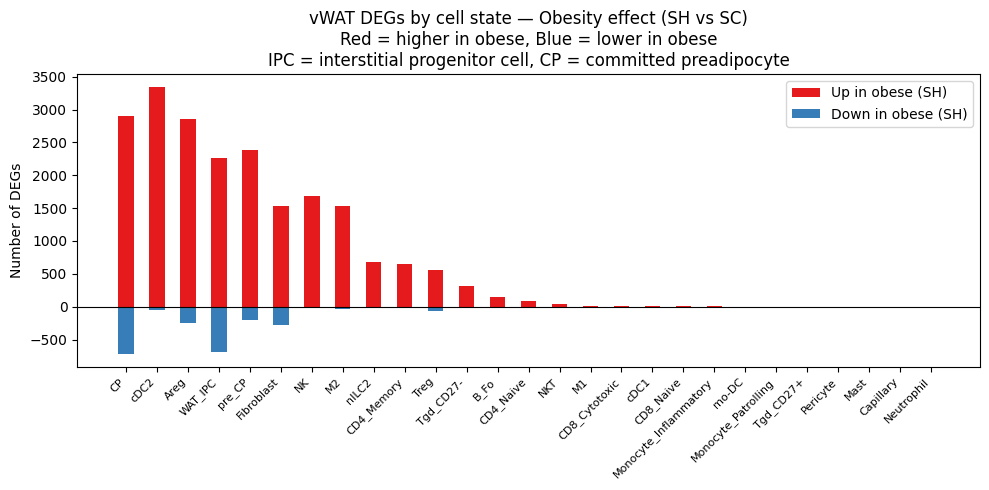


Look at this plot. The paper claims IPCs and CPs together carry 59% of vWAT DEGs.
Does your chart show ASC states dominating over immune and connective cell types?


In [27]:
# Visualize: which cell states carry the obesity signal?
# Bar chart: DEG count per state, split up/down

fig, ax = plt.subplots(figsize=(10, 5))

states  = obesity_deg_df['cell_state']
x       = np.arange(len(states))
width   = 0.5

bars_up   = ax.bar(x, obesity_deg_df['n_up'],   width, color='#E41A1C',
                   label='Up in obese (SH)')
bars_down = ax.bar(x, -obesity_deg_df['n_down'], width, color='#377EB8',
                   label='Down in obese (SH)')

ax.set_xticks(x)
ax.set_xticklabels(states, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Number of DEGs')
ax.set_title('vWAT DEGs by cell state — Obesity effect (SH vs SC)\n'
             'Red = higher in obese, Blue = lower in obese\n'
             'IPC = interstitial progenitor cell, CP = committed preadipocyte')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'vwat_obesity_degs_by_cell_state.pdf', bbox_inches='tight')
plt.show()

print("\nLook at this plot. The paper claims IPCs and CPs together carry 59% of vWAT DEGs.")
print("Does your chart show ASC states dominating over immune and connective cell types?")

In [33]:
# Compute the fraction of DEGs in ASC states (IPC + CP)
# IPC = interstitial progenitor cell (most undifferentiated ASC state)
# CP  = committed preadipocyte (ASC that has started committing to fat cell fate)

# Use word-boundary matching to avoid matching 'CP' inside longer state names
import re
ipc_cp_mask = obesity_deg_df['cell_state'].str.contains(
    r'\bIPC\b|\bCP\b|\bpre_CP\b', case=False, na=False, regex=True
)

# Print which states matched so you can verify it's correct
matched_states = obesity_deg_df.loc[ipc_cp_mask, 'cell_state'].tolist()
print(f"States matched as IPC/CP: {matched_states}")
print("Check: do these match what the paper calls IPC and CP? If not, adjust the regex.")

ipc_cp_degs = obesity_deg_df[ipc_cp_mask]['n_total'].sum()
pct_ipc_cp  = ipc_cp_degs / total_obesity_degs * 100 if total_obesity_degs > 0 else 0

print(f"\nDEGs in IPC/CP states: {ipc_cp_degs}")
print(f"Total vWAT obesity DEGs: {total_obesity_degs}")
print(f"Fraction in IPC/CP: {pct_ipc_cp:.1f}%")
print(f"\nNote: the paper's 59% figure is across all 3 contrasts.")
print(f"Your fraction is from 2 contrasts — expect it to be in the same ballpark but not identical.")

States matched as IPC/CP: ['CP', 'pre_CP']
Check: do these match what the paper calls IPC and CP? If not, adjust the regex.

DEGs in IPC/CP states: 6195
Total vWAT obesity DEGs: 23414
Fraction in IPC/CP: 26.5%

Note: the paper's 59% figure is across all 3 contrasts.
Your fraction is from 2 contrasts — expect it to be in the same ballpark but not identical.


## What genes are driving the obesity response in IPCs?

Numbers are useful for validation. But the biological insight comes from looking at *which* genes are changing. The paper identified two key programs:

1. **ECM (extracellular matrix — the protein scaffold between cells) remodeling genes** — upregulated by HFD: *Thbs1*, *Sparc*, *Col3a1*, *Col6a1*. Excess ECM deposition in fat tissue creates a fibrotic, inflammatory environment that impairs fat cell function.

2. **Circadian rhythm genes** — upregulated by training (we'll see these in contrast 2): *Dbp*, *Tef*, *Nr1d2*, *Per3*.

Let's look at the top obesity-induced genes in IPC cells specifically.

In [31]:
# Find IPC state name in this dataset
ipc_states = [s for s in obesity_results.keys() if 'IPC' in s or 'ipc' in s.lower()]
print(f"IPC-like states found: {ipc_states}")

if ipc_states:
    ipc_state = ipc_states[0]
    ipc_result = obesity_results[ipc_state]
    ipc_sig    = get_sig(ipc_result)

    print(f"\nTop 20 obesity-upregulated genes in {ipc_state} (IPC = interstitial progenitor cell):")
    top_up = ipc_sig[ipc_sig['log2FC'] > 0].sort_values('log2FC', ascending=False).head(20)
    print(top_up[['gene', 'log2FC', 'padj']].to_string(index=False))

    print(f"\nTop 20 obesity-downregulated genes in {ipc_state}:")
    top_dn = ipc_sig[ipc_sig['log2FC'] < 0].sort_values('log2FC', ascending=True).head(20)
    print(top_dn[['gene', 'log2FC', 'padj']].to_string(index=False))

    # Check for ECM genes the paper highlighted
    # ECM = extracellular matrix — the protein scaffold between cells
    # These genes build collagen fibers and adhesion proteins that stiffen fat tissue in obesity
    print(f"\nECM (extracellular matrix) genes from paper — are they in the IPC obesity DEGs?")
    ecm_hit = ipc_sig[ipc_sig['gene'].isin(ECM_GENES)]
    if len(ecm_hit) > 0:
        print(ecm_hit[['gene', 'log2FC', 'padj']].to_string(index=False))
        print("✓ ECM genes found — matches paper Finding 4")
    else:
        print("None found — check if cell state label matches paper's IPC definition")

IPC-like states found: ['WAT_IPC']

Top 20 obesity-upregulated genes in WAT_IPC (IPC = interstitial progenitor cell):
         gene    log2FC         padj
       Gprin3 23.097813 1.027020e-17
         Car4 22.962543 9.254341e-11
          Ahr 22.884422 3.235342e-14
       Il1rl1 22.504942 2.735423e-04
     Marcksl1 21.913149 1.224142e-07
       Ptprz1 21.862659 1.843547e-09
         Cd74 21.743753 3.289937e-02
      Gm11175 21.360830 7.790531e-06
          Mbp 21.027014 9.810482e-03
        Ovgp1 20.977484 4.600251e-05
       Csf2rb 20.891298 9.810482e-03
        Fgf13 20.642206 2.735423e-04
         Rgs4 20.520937 5.330900e-03
        Cryaa 20.467421 8.967261e-04
      Gm49035 20.426804 8.967261e-04
        Limd2 20.413158 8.967261e-04
       Cyp4b1 20.320658 1.796040e-02
9630014M24Rik 20.309649 2.939312e-03
         Bdnf 20.302654 3.289937e-02
       Apold1 20.273794 1.796040e-02

Top 20 obesity-downregulated genes in WAT_IPC:
         gene     log2FC     padj
        Cdhr5 -22.05778

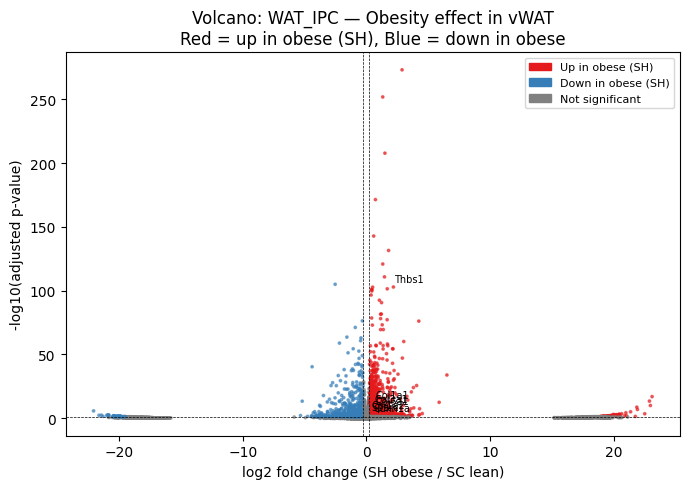

In [32]:
# Volcano plot for IPC obesity contrast
# x-axis: log2 fold change (SH vs SC) — how much higher/lower in obese animals
# y-axis: -log10(adjusted p-value) — higher = more statistically significant
# Color: red = significantly up in obese, blue = significantly down, grey = not significant

if ipc_states:
    result = obesity_results[ipc_state].copy()
    result['neg_log10_padj'] = -np.log10(result['padj'].clip(lower=1e-300))

    sig_mask = (result['padj'] < 0.05) & (result['log2FC'].abs() > 0.25)
    result['color'] = 'grey'
    result.loc[sig_mask & (result['log2FC'] > 0), 'color'] = '#E41A1C'  # up in obese
    result.loc[sig_mask & (result['log2FC'] < 0), 'color'] = '#377EB8'  # down in obese

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(result['log2FC'], result['neg_log10_padj'],
               c=result['color'], s=3, alpha=0.6, rasterized=True)

    # Label ECM genes and a few others of interest
    label_genes = ECM_GENES + ['Cdkn1a', 'Lep']
    for _, row in result[result['gene'].isin(label_genes)].iterrows():
        ax.annotate(row['gene'],
                    xy=(row['log2FC'], row['neg_log10_padj']),
                    fontsize=7, color='black',
                    xytext=(5, 5), textcoords='offset points')

    ax.axvline(-0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axvline( 0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axhline(-np.log10(0.05), color='black', linewidth=0.5, linestyle='--')

    ax.set_xlabel('log2 fold change (SH obese / SC lean)')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(f'Volcano: {ipc_state} — Obesity effect in vWAT\n'
                 f'Red = up in obese (SH), Blue = down in obese')

    legend_elements = [
        mpatches.Patch(color='#E41A1C', label='Up in obese (SH)'),
        mpatches.Patch(color='#377EB8', label='Down in obese (SH)'),
        mpatches.Patch(color='grey',    label='Not significant'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'volcano_{ipc_state}_obesity.pdf', bbox_inches='tight')
    plt.show()

## Contrast 2: Exercise effect in vWAT (TC vs SC)

**Biological question:** What does exercise training do to gene expression within each cell state in visceral fat, on a *healthy diet* (standard chow)?

- **TC** = Trained + Standard chow (exercise, no obesity)
- **SC** = Sedentary + Standard chow (baseline control)

Positive log2FC = gene is *higher* in trained animals.

The paper's key finding for this contrast: circadian rhythm genes (*Dbp*, *Tef*, *Nr1d2*, *Per3*) are upregulated by exercise training specifically in MSC states (IPC, CP). These genes control the 24-hour transcriptional rhythm of the cell and are known to regulate fat cell formation (adipogenesis).

In [36]:
# Run exercise contrast (TC vs SC) for every cell state in vWAT
exercise_results = {}

for state in vwat_cell_states:
    state_cells = vwat[vwat.obs['cell_state_label'] == state]
    result = run_wilcoxon_de(state_cells, group_a='TC', group_b='SC')

    if result is None:
        print(f"  {state}: skipped (too few cells)")
        continue

    sig = get_sig(result)
    exercise_results[state] = result
    print(f"  {state}: {result['n_a'].iloc[0]} TC cells, {result['n_b'].iloc[0]} SC cells → {len(sig)} DEGs")

1450


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  Areg: 1450 TC cells, 1555 SC cells → 2061 DEGs
317


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  B_Fo: 317 TC cells, 271 SC cells → 541 DEGs
539


...

/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  nILC2: 416 TC cells, 497 SC cells → 849 DEGs
1046


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


  pre_CP: 1046 TC cells, 1139 SC cells → 1690 DEGs
11
  vSMC: 11 TC cells, 12 SC cells → 0 DEGs


/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (


In [37]:
# Count DEGs per cell state for exercise contrast
exercise_deg_counts = []

for state, result in exercise_results.items():
    sig = get_sig(result)
    exercise_deg_counts.append({
        'cell_state': state,
        'n_up':   (sig['log2FC'] > 0).sum(),
        'n_down': (sig['log2FC'] < 0).sum(),
        'n_total': len(sig),
    })

exercise_deg_df = pd.DataFrame(exercise_deg_counts).sort_values('n_total', ascending=False)
print("DEGs per cell state — Exercise contrast (TC vs SC) in vWAT:")
print(exercise_deg_df.to_string(index=False))
print(f"\nTotal vWAT exercise DEGs: {exercise_deg_df['n_total'].sum()}")

DEGs per cell state — Exercise contrast (TC vs SC) in vWAT:
           cell_state  n_up  n_down  n_total
                   CP  4114     369     4483
                   NK  4101     166     4267
           CD4_Memory  3090      33     3123
              WAT_IPC  1800     820     2620
                 Areg  1435     626     2061
               pre_CP  1428     262     1690
                  NKT  1335      16     1351
            Tgd_CD27-  1218      14     1232
           Fibroblast   164     828      992
                nILC2   841       8      849
            CD4_Naive   774      12      786
                 B_Fo   532       9      541
            Capillary     3     531      534
        CD8_Cytotoxic   294       5      299
                 Treg   252       4      256
                 cDC2   162       6      168
            CD8_Naive   101       6      107
                   M2    33      15       48
                  Epi     7      22       29
Monocyte_Inflammatory     9       0     

In [38]:
# Check for circadian rhythm genes the paper highlighted in IPC cells
# Circadian rhythm genes control the 24-hour transcriptional cycle of a cell.
# Dbp, Tef, Nr1d2, Per3 are "clock genes" — they encode proteins that form
# the molecular clock feedback loop. The paper found exercise upregulates
# these specifically in MSC states (IPC, CP), suggesting exercise training
# resets or strengthens the fat tissue's circadian program.

if ipc_states:
    ipc_exercise = exercise_results.get(ipc_state)
    if ipc_exercise is not None:
        ipc_ex_sig = get_sig(ipc_exercise)
        print(f"Circadian rhythm genes in {ipc_state} exercise DEGs:")
        circ_hit = ipc_ex_sig[ipc_ex_sig['gene'].isin(CIRCADIAN_GENES)]
        if len(circ_hit) > 0:
            print(circ_hit[['gene', 'log2FC', 'padj']].sort_values('log2FC', ascending=False).to_string(index=False))
            print("\n✓ Circadian genes upregulated by exercise in IPC — matches paper Finding 5")
        else:
            print("None found — may be in a different ASC state or below threshold")
            print("Try checking CP states too (committed preadipocytes)")

        print(f"\nTop 15 exercise-upregulated genes in {ipc_state}:")
        top_ex_up = ipc_ex_sig[ipc_ex_sig['log2FC'] > 0].sort_values('log2FC', ascending=False).head(15)
        print(top_ex_up[['gene', 'log2FC', 'padj']].to_string(index=False))

Circadian rhythm genes in WAT_IPC exercise DEGs:
 gene    log2FC          padj
  Hlf  3.623930 3.333459e-136
  Dbp  3.235552 1.703709e-292
  Tef  1.679984 7.890084e-105
 Per3  1.551802  1.867657e-65
Nr1d2  1.286890  2.734413e-84
Clock -0.298048  2.714653e-02

✓ Circadian genes upregulated by exercise in IPC — matches paper Finding 5

Top 15 exercise-upregulated genes in WAT_IPC:
         gene    log2FC         padj
          Mbp 22.015970 1.396948e-07
       Stk17b 21.568069 4.563612e-02
      Gm45716 20.848360 2.537881e-03
        Ovgp1 20.837269 3.625384e-04
        Itgb4 20.728445 1.568125e-03
        Dusp9 20.593664 1.734108e-02
      Pglyrp1 20.501221 1.079445e-02
      Noxred1 20.336939 4.082137e-03
          Ddn 19.984610 1.079445e-02
A230083N12Rik 19.978083 1.734108e-02
     Hs3st3a1 19.962971 1.734108e-02
       Rgs7bp 19.954048 1.734108e-02
      Gm37422 19.936747 1.079445e-02
      Gm49035 19.916412 1.734108e-02
         Knl1 19.867918 1.079445e-02


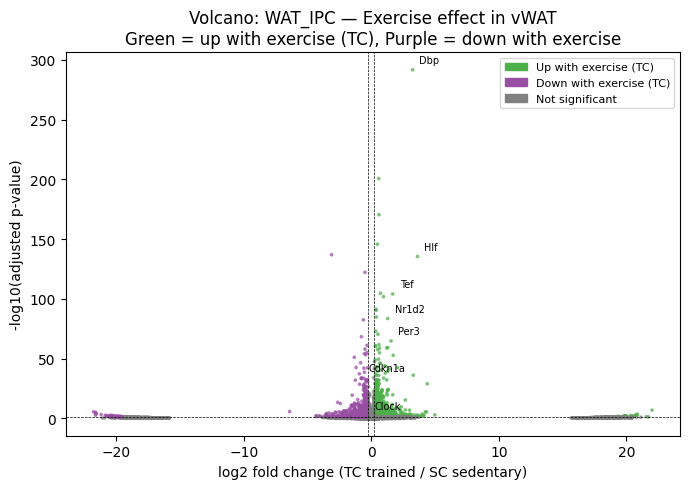

In [39]:
# Volcano plot for IPC exercise contrast
if ipc_states and ipc_state in exercise_results:
    result = exercise_results[ipc_state].copy()
    result['neg_log10_padj'] = -np.log10(result['padj'].clip(lower=1e-300))

    sig_mask = (result['padj'] < 0.05) & (result['log2FC'].abs() > 0.25)
    result['color'] = 'grey'
    result.loc[sig_mask & (result['log2FC'] > 0), 'color'] = '#4DAF4A'  # up with exercise
    result.loc[sig_mask & (result['log2FC'] < 0), 'color'] = '#984EA3'  # down with exercise

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(result['log2FC'], result['neg_log10_padj'],
               c=result['color'], s=3, alpha=0.6, rasterized=True)

    # Label circadian genes and Cdkn1a (cell cycle regulator — paper highlighted this)
    label_genes = CIRCADIAN_GENES + ['Cdkn1a']
    for _, row in result[result['gene'].isin(label_genes)].iterrows():
        ax.annotate(row['gene'],
                    xy=(row['log2FC'], row['neg_log10_padj']),
                    fontsize=7, color='black',
                    xytext=(5, 5), textcoords='offset points')

    ax.axvline(-0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axvline( 0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axhline(-np.log10(0.05), color='black', linewidth=0.5, linestyle='--')

    ax.set_xlabel('log2 fold change (TC trained / SC sedentary)')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(f'Volcano: {ipc_state} — Exercise effect in vWAT\n'
                 f'Green = up with exercise (TC), Purple = down with exercise')

    legend_elements = [
        mpatches.Patch(color='#4DAF4A', label='Up with exercise (TC)'),
        mpatches.Patch(color='#984EA3', label='Down with exercise (TC)'),
        mpatches.Patch(color='grey',    label='Not significant'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'volcano_{ipc_state}_exercise.pdf', bbox_inches='tight')
    plt.show()

NameError: name 'circadian_genes' is not defined

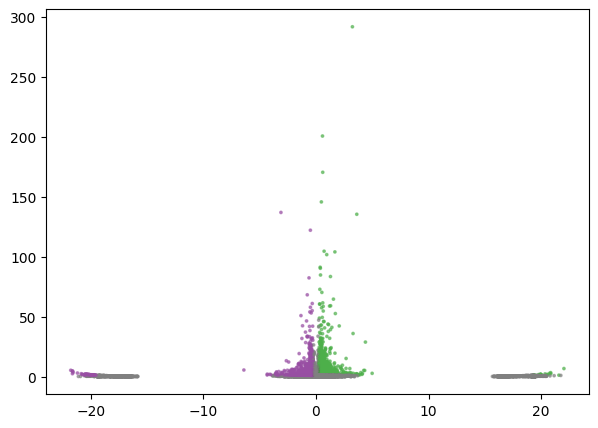

In [40]:
# Volcano plot for IPC exercise contrast
if ipc_states and ipc_state in exercise_results:
    result = exercise_results[ipc_state].copy()
    result['neg_log10_padj'] = -np.log10(result['padj'].clip(lower=1e-300))

    sig_mask = (result['padj'] < 0.05) & (result['log2FC'].abs() > 0.25)
    result['color'] = 'grey'
    result.loc[sig_mask & (result['log2FC'] > 0), 'color'] = '#4DAF4A'  # up with exercise
    result.loc[sig_mask & (result['log2FC'] < 0), 'color'] = '#984EA3'  # down with exercise

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(result['log2FC'], result['neg_log10_padj'],
               c=result['color'], s=3, alpha=0.6, rasterized=True)

    # Label circadian genes
    label_genes = circadian_genes + ['Cdkn1a']
    for _, row in result[result['gene'].isin(label_genes)].iterrows():
        ax.annotate(row['gene'],
                    xy=(row['log2FC'], row['neg_log10_padj']),
                    fontsize=7, color='black',
                    xytext=(5, 5), textcoords='offset points')

    ax.axvline(-0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axvline( 0.25, color='black', linewidth=0.5, linestyle='--')
    ax.axhline(-np.log10(0.05), color='black', linewidth=0.5, linestyle='--')

    ax.set_xlabel('log2 fold change (TC trained / SC sedentary)')
    ax.set_ylabel('-log10(adjusted p-value)')
    ax.set_title(f'Volcano: {ipc_state} — Exercise effect in vWAT\n'
                 f'Green = up with exercise, Purple = down with exercise')

    legend_elements = [
        mpatches.Patch(color='#4DAF4A', label='Up with exercise (TC)'),
        mpatches.Patch(color='#984EA3', label='Down with exercise (TC)'),
        mpatches.Patch(color='grey',    label='Not significant'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'volcano_{ipc_state}_exercise.pdf', bbox_inches='tight')
    plt.show()

## Side-by-side: obesity vs exercise in vWAT (partial Figure 4G)

The paper's Figure 4G shows both contrasts as a heatmap where each cell = DEG count for a cell state × contrast combination. Let's reproduce the obesity and exercise columns.

In [ ]:
# Build a combined DEG count table: rows = cell states, cols = contrasts
all_states = sorted(set(list(obesity_results.keys()) + list(exercise_results.keys())))

rows = []
for state in all_states:
    row = {'cell_state': state}

    for contrast_label, results_dict in [('Obesity\n(SH vs SC)', obesity_results),
                                          ('Exercise\n(TC vs SC)', exercise_results)]:
        if state in results_dict:
            sig = get_sig(results_dict[state])
            row[f'{contrast_label}_up']    = (sig['log2FC'] > 0).sum()
            row[f'{contrast_label}_down']  = (sig['log2FC'] < 0).sum()
            row[f'{contrast_label}_total'] = len(sig)
        else:
            row[f'{contrast_label}_up']    = 0
            row[f'{contrast_label}_down']  = 0
            row[f'{contrast_label}_total'] = 0

    rows.append(row)

combined_df = pd.DataFrame(rows).set_index('cell_state')

# Sort by total DEGs across both contrasts
combined_df['sort_key'] = combined_df.filter(like='_total').sum(axis=1)
combined_df = combined_df.sort_values('sort_key', ascending=False).drop('sort_key', axis=1)

# Heatmap of total DEG counts — reproduces the structure of Figure 4G
total_cols = [c for c in combined_df.columns if '_total' in c]
heatmap_data = combined_df[total_cols].copy()
heatmap_data.columns = ['Obesity (SH vs SC)', 'Exercise (TC vs SC)']

fig, ax = plt.subplots(figsize=(5, max(6, len(all_states) * 0.35)))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='d',
    cmap='Reds',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Number of DEGs'},
)
ax.set_title('vWAT DEG counts by cell state and contrast\n'
             'Reproduces Figure 4G (obesity + exercise columns)\n'
             'IPC=interstitial progenitor cell, CP=committed preadipocyte')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'vwat_deg_heatmap_fig4G.pdf', bbox_inches='tight')
plt.show()

print("\nCompare this to Figure 4G in the paper.")
print("The IPC and CP rows should have the most DEGs.")

NameError: name 'exercise_results' is not defined

## Save results

Save all DE results to CSV for use in downstream notebooks:
- NB7d (pathway enrichment on these DEG lists)
- NB8 (comparison against pseudobulk DESeq2 — the methodologically better approach)
- NB9 (Decoupler TF activity uses these DEG lists to prioritize TFs)

In [ ]:
# Combine all results into one flat DataFrame
all_results = []

for contrast_label, results_dict in [('obesity_SH_vs_SC', obesity_results),
                                      ('exercise_TC_vs_SC', exercise_results)]:
    for state, result in results_dict.items():
        result = result.copy()
        result['cell_state'] = state
        result['tissue']     = 'vWAT'
        result['contrast_label'] = contrast_label
        result['is_sig'] = (
            (result['padj'] < 0.05) & (result['log2FC'].abs() > 0.25)
        )
        all_results.append(result)

all_results_df = pd.concat(all_results, ignore_index=True)

# Save full results
out_path = OUT_DIR / 'degs_vwat_cell_state_wilcoxon.csv'
all_results_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows: {len(all_results_df):,} (all genes × all states × all contrasts)")

# Save significant DEGs only
sig_only = all_results_df[all_results_df['is_sig']]
sig_path = OUT_DIR / 'degs_vwat_cell_state_wilcoxon_sig_only.csv'
sig_only.to_csv(sig_path, index=False)
print(f"Saved significant DEGs: {sig_path}")
print(f"Total significant DEGs: {len(sig_only):,}")
print(f"\nBreakdown:")
print(sig_only.groupby(['contrast_label', 'cell_state']).size().to_string())

NameError: name 'exercise_results' is not defined

## Concept check

Before moving to NB7d (pathway enrichment), make sure you can answer these in your own words:

1. **Why did we run the Wilcoxon test separately for each cell state, rather than on all vWAT cells at once?**
   *(Hint: if you run it on all cells, what happens to a gene that's only upregulated in IPCs but flat everywhere else?)*

2. **The IPC result shows ECM genes upregulated by obesity. What does that mean biologically?**
   *(Hint: ECM = extracellular matrix = the protein scaffold between cells. What happens to tissue function when this scaffold gets thicker?)*

3. **Why does the exercise contrast (TC vs SC) show fewer DEGs than obesity (SH vs SC)?**
   *(Think about effect size: HFD is a strong metabolic perturbation over 6 weeks. Voluntary wheel running is a milder intervention.)*

4. **We used Wilcoxon here because the paper did. What's the statistical problem with this approach?**
   *(Hint: the 50,000 vWAT cells came from ~13 mice per group. Are those cells independent observations?)*

Write your answers in `biology_notes.md` before running NB7d.